<a href="https://colab.research.google.com/github/Jean1489/CLAIR/blob/main/notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Sistema de Registro Académico y Admisiones __ - (1).pdf',
 'acuerdoConfidencialidad (2).pdf',
 'D10.pdf',
 'Acuerdo de confidencialidad Monitores ASES(1) (2).pdf',
 'CC - Yhan Carlos Trujillo (4).pdf',
 'ENGLISH PLEASE.rar',
 'Classroom',
 'Formulario sin título (1).gform',
 'Colaborativos.gdoc',
 'Diagrama Practica 2. Oscar Eduardo Restrepo.docx',
 'Formulario sin título.gform',
 'Sitio web sin título.gsite',
 'Diagrama Practica 2. Oscar Eduardo Restrepo.gdoc',
 'Anyfile Notepad Files',
 '1.1 Primer Parcial Álgebra Lineal Actividad No.1 (1).gdoc',
 'Calificaciones Parciales Álgebra Lineal.xls',
 'Calificaciones Parciales Álgebra Lineal.gsheet',
 'Cálcullo II',
 'CALCULO II (2020-10-15 at 12:00 GMT-7).gdrive',
 'Monografia que va a terminar Carliños.docx',
 'MONOGRAFIA.docx',
 'Parcial3_FisicaI_Yhan-Carlos.docx',
 'ELEC..rar',
 'Parcial_Fisica.pdf',
 'grupo 9.docx',
 'Quiz_1_YHAN_CARLOST.pdf',
 'YhanCarlos_Quiz2.pdf',
 'Quiz3_Yhan.pdf',
 'Yhan.pdf',
 'Punto3_YCTC.pdf',
 'Pun

In [3]:
!git clone https://github.com/Jean1489/CLAIR.git

Cloning into 'CLAIR'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 6), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 8.13 KiB | 4.06 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [4]:
%cd /content/CLAIR
!git config user.email "yhan.trujillo@correounivalle.edu.co"
!git config user.name "Jean1489"

/content/CLAIR


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [7]:
# Ruta base del dataset
base_path = '/content/drive/MyDrive/CLAIR/data/raw/Training'

# Contar imágenes por clase
clases = os.listdir(base_path)
for clase in clases:
    ruta_clase = os.path.join(base_path, clase)
    cantidad = len(os.listdir(ruta_clase))
    print(f'{clase}: {cantidad} imágenes')

glioma_tumor: 826 imágenes
meningioma_tumor: 822 imágenes
no_tumor: 395 imágenes
pituitary_tumor: 827 imágenes


no_tumor tiene 395 imágenes mientras las otras tienen alrededor de 826. Es casi la mitad. Eso es un problema porque el modelo va a ver muchos más ejemplos de tumor que de no_tumor durante el entrenamiento, lo que puede sesgar las predicciones.

In [8]:
base_path_test = '/content/drive/MyDrive/CLAIR/data/raw/Testing'

clases_test = os.listdir(base_path_test)
for clase in clases_test:
    ruta_clase = os.path.join(base_path_test, clase)
    cantidad = len(os.listdir(ruta_clase))
    print(f'{clase}: {cantidad} imágenes')

glioma_tumor: 100 imágenes
meningioma_tumor: 115 imágenes
no_tumor: 105 imágenes
pituitary_tumor: 74 imágenes


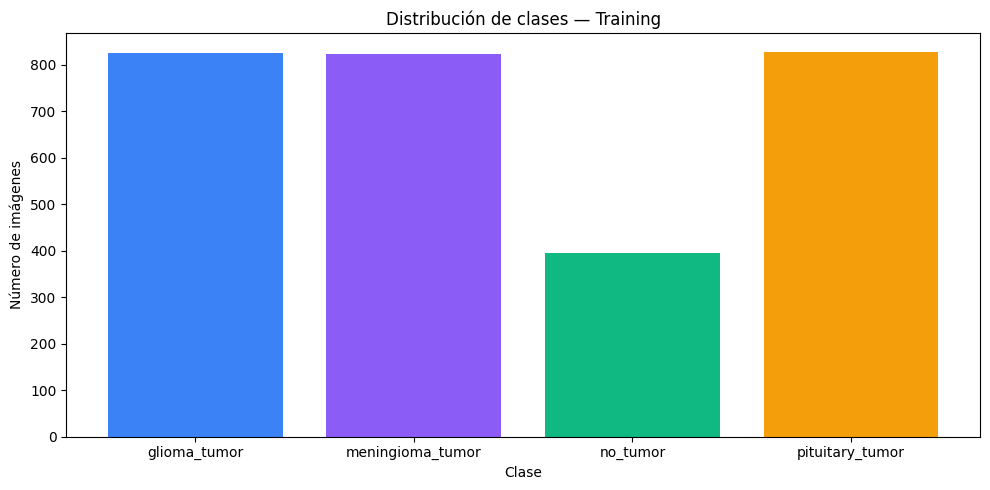

In [10]:
clases_nombres = []
cantidades = []

for clase in os.listdir(base_path):
    ruta_clase = os.path.join(base_path, clase)
    clases_nombres.append(clase)
    cantidades.append(len(os.listdir(ruta_clase)))

plt.figure(figsize=(10, 5))
plt.bar(clases_nombres, cantidades, color=['#3b82f6', '#8b5cf6', '#10b981', '#f59e0b'])
plt.title('Distribución de clases — Training')
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/content/drive/MyDrive/CLAIR/outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'distribucion_clases.png'))
plt.show()

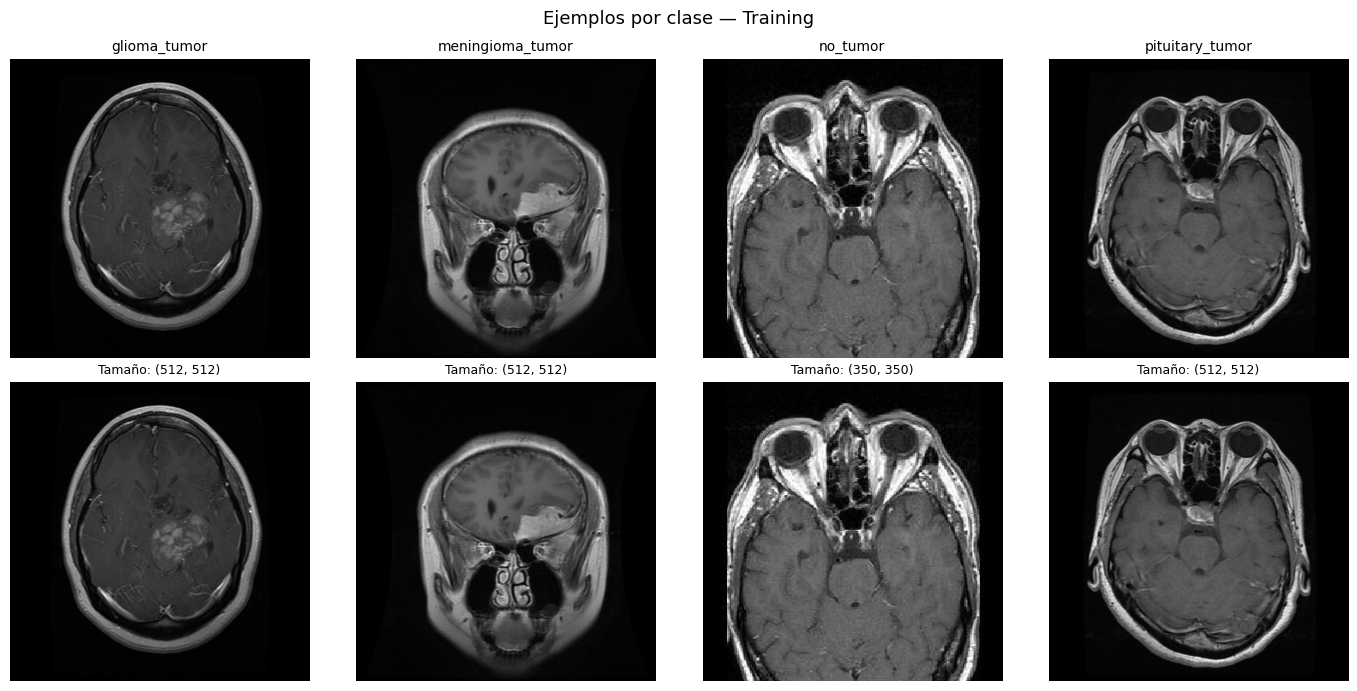

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, clase in enumerate(clases_nombres):
    ruta_clase = os.path.join(base_path, clase)
    imagen = os.listdir(ruta_clase)[0]
    img = Image.open(os.path.join(ruta_clase, imagen))

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(clase, fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Tamaño: {img.size}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Ejemplos por clase — Training', fontsize=13)
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = '/content/drive/MyDrive/CLAIR/outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'ejemplos_clases.png'))
plt.show()

In [12]:
for clase in clases_nombres:
    ruta_clase = os.path.join(base_path, clase)
    imagen = os.listdir(ruta_clase)[0]
    img = Image.open(os.path.join(ruta_clase, imagen))
    print(f'{clase}: {img.size}')

glioma_tumor: (512, 512)
meningioma_tumor: (512, 512)
no_tumor: (350, 350)
pituitary_tumor: (512, 512)


Hallazgos


1.   El dataset se encuentra desbalanceado exactamente en el training, no hay muchas imagenes de la clase no_tumor
2.   Se encontró que las imagenes son de diferentes tamaños por lo que se debe redimensionar todo (224*244)
3. El split Training/Testing es aproximadamente 14%





In [13]:
import numpy as np

resultados = []

for clase in clases_nombres:
    ruta_clase = os.path.join(base_path, clase)
    imagenes = os.listdir(ruta_clase)[:50]  # tomamos 50 por clase para no tardar mucho

    brillos = []
    contrastes = []

    for img_nombre in imagenes:
        img = cv2.imread(os.path.join(ruta_clase, img_nombre), cv2.IMREAD_GRAYSCALE)
        brillos.append(img.mean())
        contrastes.append(img.std())

    resultados.append({
        'clase': clase,
        'brillo_promedio': round(np.mean(brillos), 2),
        'contraste_promedio': round(np.mean(contrastes), 2)
    })

df = pd.DataFrame(resultados)
print(df)

              clase  brillo_promedio  contraste_promedio
0      glioma_tumor            43.33               42.21
1  meningioma_tumor            32.52               44.97
2          no_tumor            50.76               49.91
3   pituitary_tumor            56.07               45.67


En imágenes naturales como fotos de perros o carros, voltear horizontalmente tiene sentido. Pero en MRI hay que tener cuidado porque el cerebro tiene lateralidad, izquierda y derecha no son lo mismo clínicamente.
Entonces la estrategia de augmentation segura para MRI es:

✅ Rotaciones pequeñas (±15°)
✅ Variaciones de brillo y contraste
✅ Zoom leve
⚠️ Flip horizontal con cuidado

In [14]:
corruptas = []

for clase in clases_nombres:
    ruta_clase = os.path.join(base_path, clase)
    for img_nombre in os.listdir(ruta_clase):
        try:
            img = Image.open(os.path.join(ruta_clase, img_nombre))
            img.verify()
        except Exception as e:
            corruptas.append(os.path.join(clase, img_nombre))

print(f'Imágenes corruptas encontradas: {len(corruptas)}')
if corruptas:
    for c in corruptas:
        print(c)

Imágenes corruptas encontradas: 0
